# Week 4 Assignment

## Assignment Details
The `1962_2006_walmart_store_openings.csv` file is available here:
https://raw.githubusercontent.com/plotly/datasets/master/1962_2006_walmart_store_openings.csv

It contains information on Walmart store openings between the years 1962-2006. Some explanations on the meaning of variable names:

- `storenum`: the unique store number (storenumber is an id, not a count)	
- `OPENDATE`: the date the original store was opened
- `date_super`: the date the store became a super store
- `conversion`: whether the original store was converted to a super store
- `STRCITY`: the name of the city where the store is located
- `STRSTATE`: the state where the store is located

When answering the questions below, please make sure to examine the dataset carefully and understand if it needs further data aggregation, cleaning, or wrangling before you calcualte the answers to your questions.

#### [GRADED  TASK 1]
Import the dataset and ensure all columns of data are properly read into an appropriate data structure.

In [7]:
# Your answer to Graded Task 1 here:

# Import pandas library
import pandas

# Read the Walmart store openings dataset from the provided URL
url = "https://raw.githubusercontent.com/plotly/datasets/master/1962_2006_walmart_store_openings.csv"
walmart_df = pandas.read_csv(url)

# Display the first few rows of the dataset
print("----- First 5 Rows -----")
print(walmart_df.head())

# Display dataset information: column names, data types, and non-null counts
print("\n----- Dataset Info -----")
print(walmart_df.info())

# Display basic statistical summary (for numeric columns)
print("\n----- Summary Statistics -----")
print(walmart_df.describe())

# Check for missing values in each column
print("\n----- Missing Values -----")
print(walmart_df.isnull().sum())

# Display column names and data types separately for clarity
print("\n----- Column Names -----")
print(walmart_df.columns.tolist())

print("\n----- Data Types -----")
print(walmart_df.dtypes)


----- First 5 Rows -----
   storenum OPENDATE date_super  conversion  st  county  \
0         1   7/1/62     3/1/97         1.0   5       7   
1         2   8/1/64     3/1/96         1.0   5       9   
2         4   8/1/65     3/1/02         1.0   5       7   
3         8  10/1/67     3/1/93         1.0   5      29   
4         7  10/1/67        NaN         NaN   5     119   

               STREETADDR            STRCITY STRSTATE  ZIPCODE   type_store  \
0        2110 WEST WALNUT             Rogers       AR    72756  Supercenter   
1        1417 HWY 62/65 N           Harrison       AR    72601  Supercenter   
2       2901 HWY 412 EAST     Siloam Springs       AR    72761  Supercenter   
3   1621 NORTH BUSINESS 9          Morrilton       AR    72110  Supercenter   
4  3801 CAMP ROBINSON RD.  North Little Rock       AR    72118     Wal-Mart   

         LAT       LON  MONTH  DAY  YEAR  
0  36.342235 -94.07141      7    1  1962  
1  36.236984 -93.09345      8    1  1964  
2  36.179905 -94

#### [GRADED  TASK 2]

- which state has the `7th highest` total number of Walmart super stores?
- which city has the `5th highest` total number of Walmart stores (super stores and regular stores combined)?

In [2]:
# Your answer to Graded Task 2 here:

# Filter super stores (non-null 'date_super')
super_store_data = walmart_df[walmart_df['date_super'].notnull()]

# Count and sort states by super store count
super_store_by_state = super_store_data.groupby('STRSTATE').size().reset_index(name='super_store_count')
super_store_by_state_sorted = super_store_by_state.sort_values(by='super_store_count', ascending=False).reset_index(drop=True)

# 7th highest state
seventh_highest_super_state = super_store_by_state_sorted.iloc[6]
print("7th highest state (by Walmart super stores):")
print(seventh_highest_super_state)

# Count and sort cities by total store count
store_by_city = walmart_df.groupby('STRCITY').size().reset_index(name='total_store_count')
store_by_city_sorted = store_by_city.sort_values(by='total_store_count', ascending=False).reset_index(drop=True)

# 5th highest city
fifth_highest_city = store_by_city_sorted.iloc[4]
print("\n5th highest city (by total Walmart stores):")
print(fifth_highest_city)


7th highest state (by Walmart super stores):
STRSTATE             AL
super_store_count    76
Name: 6, dtype: object

5th highest city (by total Walmart stores):
STRCITY              San Antonio
total_store_count             10
Name: 4, dtype: object


#### [GRADED  TASK 3]
Write a function that takes as arguments:

1. the data frame you generated above from importing the Walmart dataset
2. a state abbreviaton (e.g. `AR`)

and, then, the function returns a pandas Data Frame with 2 columns: 
1. a column called `date` that contains the date (note that date must be properly ordered)
2. a column called `cumsum` that contains the `cumulative` (i.e. `running`) sum of the number of stores over time opened in that state


In [ ]:
# Your answer to Graded Task 3 here:

def cumulative_stores_by_state(dataframe, state_abbr):
    # Filter data for the given state
    state_data = dataframe[dataframe['STRSTATE'] == state_abbr].copy()

    # Convert 'OPENDATE' to datetime and sort by date
    state_data['OPENDATE'] = pandas.to_datetime(state_data['OPENDATE'])
    state_data = state_data.sort_values('OPENDATE')

    # Calculate cumulative number of stores
    cumulative_data = (
        state_data.groupby('OPENDATE')
        .size()
        .cumsum()
        .reset_index(name='cumsum')
        .rename(columns={'OPENDATE': 'date'})
    )

    return cumulative_data


# Call the function
result_df = cumulative_stores_by_state(walmart_df, 'ID')
print(result_df.head())


        date  cumsum
0 1992-11-02       3
1 1993-01-05       5
2 1993-07-27       6
3 1993-08-31       7
4 1996-07-23       8


C:\Users\dhrumil\AppData\Local\Temp\ipykernel_18380\1747112190.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  state_data['OPENDATE'] = pandas.to_datetime(state_data['OPENDATE'])


#### [GRADED  TASK 4]
Using any of the three plotting libraries we discussed (`matplotlib`, `seaborn`, or `bokeh`), plot the time series of cumulative store count over time in the state of Idaho (ID).

C:\Users\dhrumil\AppData\Local\Temp\ipykernel_18380\1747112190.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  state_data['OPENDATE'] = pandas.to_datetime(state_data['OPENDATE'])


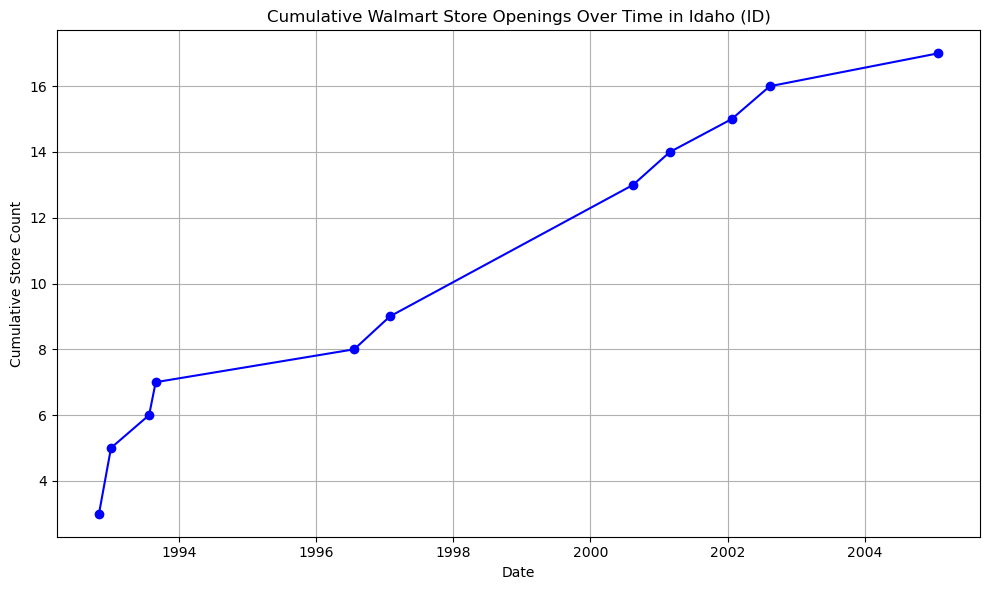

In [4]:
# Your answer to Graded Task 4 here:

import matplotlib.pyplot as plt

# Get cumulative store data for Idaho
idaho_data = cumulative_stores_by_state(walmart_df, 'ID')

# Plot the cumulative store count over time
plt.figure(figsize=(10, 6))
plt.plot(idaho_data['date'], idaho_data['cumsum'], marker='o', linestyle='-', color='blue')
plt.title('Cumulative Walmart Store Openings Over Time in Idaho (ID)')
plt.xlabel('Date')
plt.ylabel('Cumulative Store Count')
plt.grid(True)
plt.tight_layout()
plt.show()


#### [GRADED  TASK 5]
Using any of the three plotting libraries we discussed (`matplotlib`, `seaborn`, or `bokeh`), plot a bar chart that shows the `total` number of Walmart stores in each of the states that directly border the state of Utah (Arkansas (AR)).

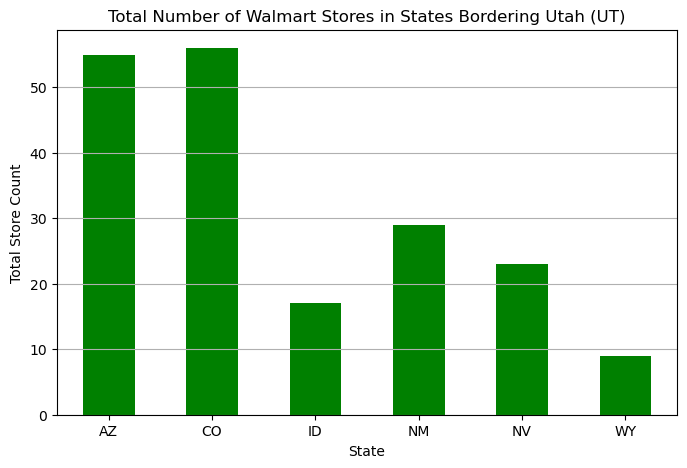

In [8]:
# Your asnwer to Graded Task 5 here:

# List of states that share a border with Utah
border_states = ['ID', 'NV', 'AZ', 'CO', 'WY', 'NM']

# Filter data for only those border states
border_df = walmart_df[walmart_df['STRSTATE'].isin(border_states)]

# Count total stores for each border state and sort alphabetically
border_counts = border_df['STRSTATE'].value_counts().sort_index()

# Create a bar chart to show total store count by state
plt.figure(figsize=(8, 5))
border_counts.plot(kind='bar', color='green')

# Add chart title and labels
plt.title("Total Number of Walmart Stores in States Bordering Utah (UT)")
plt.xlabel("State")
plt.ylabel("Total Store Count")

# Keep state labels straight and add horizontal grid lines
plt.xticks(rotation=0)
plt.grid(axis='y')

# Show the plot
plt.show()